This notebook should help answer the following questions:

1) How many observations are there?
2) What columns exist?
3) What is cnt?
4) Are there missing values?
5) What does the datetime look like?
6) Is the data chronologically ordered?
7) Are there timestamp gaps?
8) What does hourly demand look like?
9) What does weekly demand look like?
10) What does monthly/seasonal demand look like?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [5]:
df = pd.read_csv('C:\\Users\\User\\Desktop\\basisbench\\data\\raw\\hour.csv')

#### Understand the data ####

See the shape, details about the data and see if there are any missing values.

In [6]:
df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


In [ ]:
df.columns #* features

Index(['instant', 'dteday', 'season', 'yr', 'mnth', 'hr', 'holiday', 'weekday',
       'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed',
       'casual', 'registered', 'cnt'],
      dtype='str')

In [8]:
df.shape #*(n_observations, n_features)

(17379, 17)

In [ ]:
df.isna() #* data frame with all missing values rows ----> no missing values

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17374,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
17375,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
17376,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
17377,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [ ]:
df.isna().sum() #* confirmation of no missing values

instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

### Understand the Target ###

See different statistics that describe the target variable; These include
1) mean
2) counts
3) standard deviation
4) The quantiles

In [15]:
df['cnt'].describe()

count    17379.000000
mean       189.463088
std        181.387599
min          1.000000
25%         40.000000
50%        142.000000
75%        281.000000
max        977.000000
Name: cnt, dtype: float64

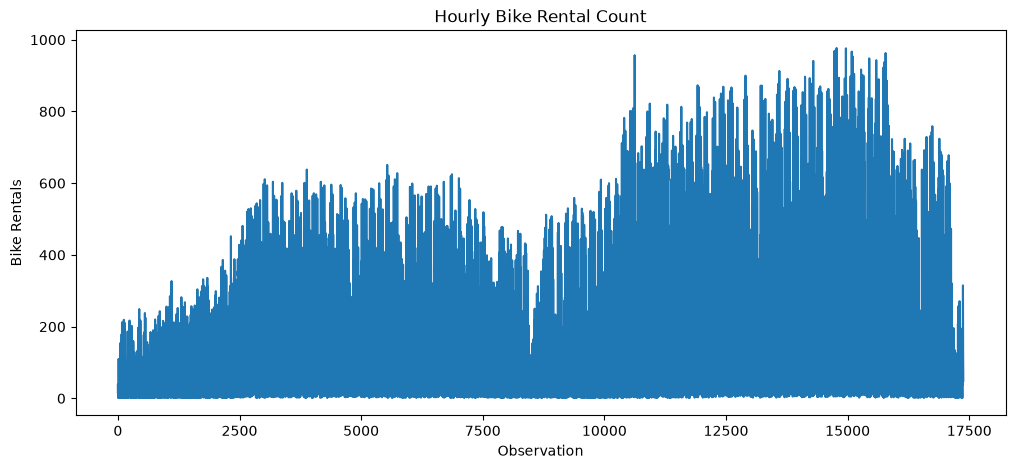

In [17]:
plt.figure(figsize=(12,5))

plt.plot(df['cnt'])
plt.xlabel('Observation')
plt.ylabel('Bike Rentals')
plt.title('Hourly Bike Rental Count')

plt.show()

### Understand the Input features ####

In [33]:
df

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0000,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0000,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0000,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0000,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0000,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17374,17375,2012-12-31,1,1,12,19,0,1,1,2,0.26,0.2576,0.60,0.1642,11,108,119
17375,17376,2012-12-31,1,1,12,20,0,1,1,2,0.26,0.2576,0.60,0.1642,8,81,89
17376,17377,2012-12-31,1,1,12,21,0,1,1,1,0.26,0.2576,0.60,0.1642,7,83,90
17377,17378,2012-12-31,1,1,12,22,0,1,1,1,0.26,0.2727,0.56,0.1343,13,48,61


In [31]:
df['mnth'].unique()

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12])

In [32]:
df['season'].unique(), df['yr'].unique()

(array([1, 2, 3, 4]), array([0, 1]))

### Get proper time stamps ####

In [36]:
df['datetime'] = (
    pd.to_datetime(df['dteday']) +
    pd.to_timedelta(df['hr'], unit ='h')
)

In [42]:
df[[ 'dteday','hr', 'datetime', 'cnt']].head()

,dteday,hr,datetime,cnt
0,2011-01-01,0,2011-01-01 00:00:00,16
1,2011-01-01,1,2011-01-01 01:00:00,40
2,2011-01-01,2,2011-01-01 02:00:00,32
3,2011-01-01,3,2011-01-01 03:00:00,13
4,2011-01-01,4,2011-01-01 04:00:00,1


In [46]:
df['datetime'].diff().value_counts().head()

datetime
0 days 01:00:00    17303
0 days 02:00:00       64
0 days 03:00:00        6
0 days 13:00:00        1
0 days 23:00:00        1
Name: count, dtype: int64

In [47]:
df['datetime'].is_monotonic_increasing

True

Look at the average rental count by hour

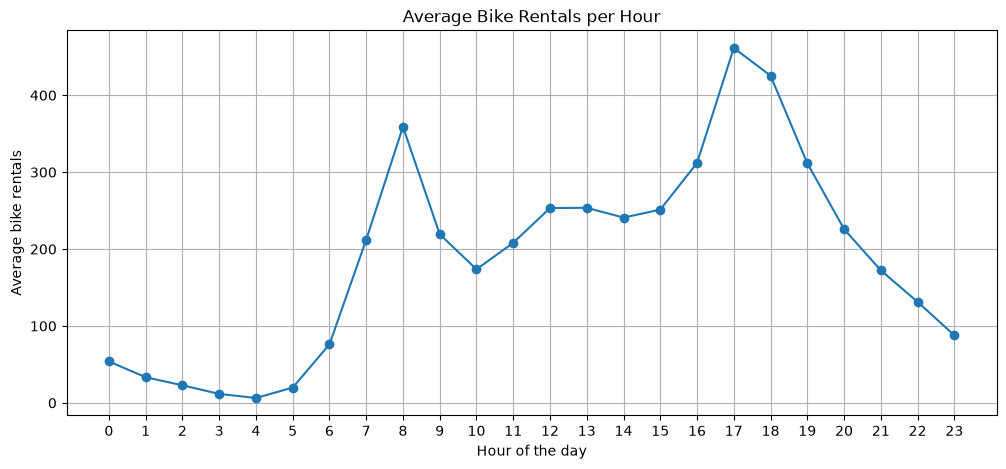

In [75]:
hourly_pattern = df.groupby('hr')['cnt'].mean()

plt.figure(figsize=(12,5))
plt.plot(hourly_pattern, marker='o')

plt.xlabel('Hour of the day')
plt.ylabel('Average bike rentals')
plt.title('Average Bike Rentals per Hour')

plt.grid(visible=True)
plt.xticks(range(24))
plt.show()

The above plot shows that the average rental county by hour can be best represented by a sinosoidal approximation.

Look at the within-day structure.

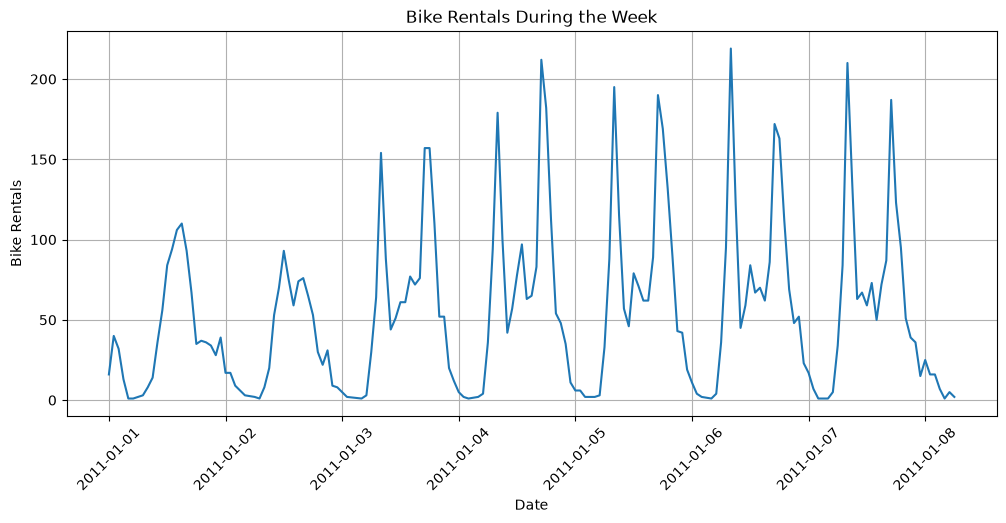

In [ ]:
first_week = df.iloc[:24 * 7]

plt.figure(figsize=(12,5))
plt.plot(first_week['datetime'], first_week['cnt'])

plt.xlabel("Date")
plt.ylabel("Bike Rentals")
plt.title("Bike Rentals During the Week")

plt.grid(visible=True)
plt.xticks(rotation=45)
plt.show()

Look at the day of the week behavior

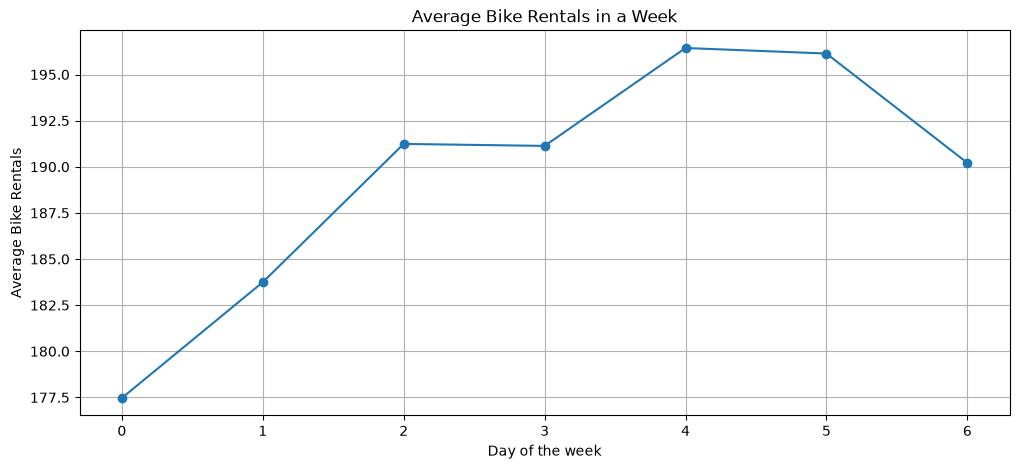

In [73]:
weekday_pattern = df.groupby('weekday')['cnt'].mean()

plt.figure(figsize=(12,5))

plt.plot(weekday_pattern, marker='o')
plt.xlabel('Day of the week')
plt.ylabel("Average Bike Rentals")
plt.title('Average Bike Rentals in a Week')
plt.grid(visible=True)

plt.show()

Look at the monthly behavior

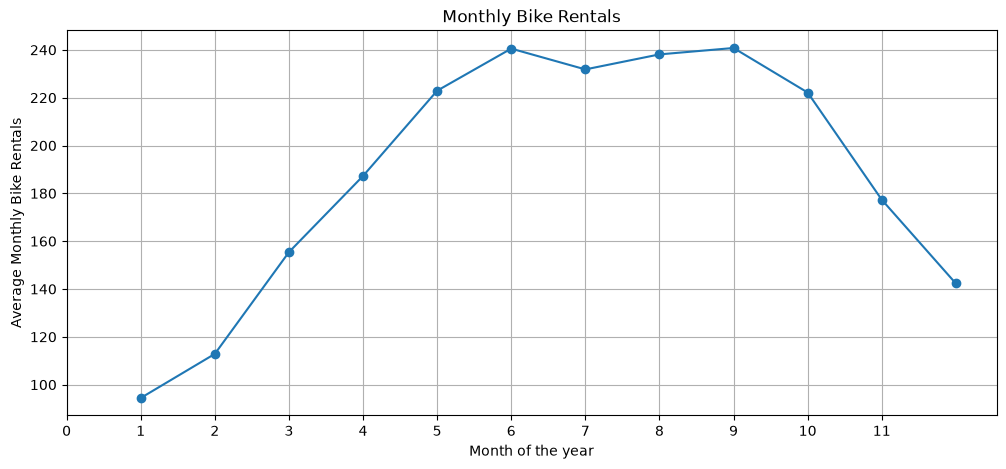

In [85]:
monthly = df.groupby('mnth')['cnt'].mean()

plt.figure(figsize=(12,5))
plt.plot(monthly, marker='o')
plt.xlabel('Month of the year')
plt.ylabel('Average Monthly Bike Rentals')
plt.title('Monthly Bike Rentals')

plt.grid(visible=True)
plt.xticks(range(12))
plt.show()